<div style="background-color:#84bfef; padding:20px; border-radius:10px">

# Desafío #1 | Equipo 31 | Análisis de Absentismo y Bienestar Laboral
</div>

Este notebook responde la pregunta de negocio del perfil **Analista de Absentismo y Bienestar Laboral**:

> ¿Cuál es la magnitud del absentismo laboral en la empresa y cómo varía a lo largo del año? 
> ¿Cómo podemos anticiparnos para reforzar la planificación de recursos humanos y garantizar la continuidad operativa?

El análisis combina KPI, tablas y gráficos para preparar conclusiones de negocio y materiales de dashboard/presentación.


## 1. Enfoque del análisis

Se trabaja con registros de absentismo asociados a empleados (`ID`). Como un empleado puede aparecer muchas veces, se distinguen dos niveles:

- **Registro:** fila individual del dataset; útil para meses, días, motivos y horas.
- **Empleado:** agregación por `ID`; útil para medir concentración y carga acumulada.


## 2. Librerías y configuración


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from IPython.display import Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")
COLOR_PRINCIPAL = "#2F6F73"
COLOR_SECUNDARIO = "#D68C45"
COLOR_ALERTA = "#B94E48"
COLOR_GRIS = "#6B7280"


## 3. Carga de datos


In [2]:
DATA_FILE = '../../Data/clean/clean_data_25052026.csv'
RRHH = pd.read_csv(DATA_FILE)

print("Archivo cargado:", DATA_FILE)
print("Dimensiones:", RRHH.shape)
RRHH.head()


Archivo cargado: ../../Data/clean/clean_data_25052026.csv
Dimensiones: (740, 27)


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
0,14,11.00,Sistema digestivo,11.00,Noviembre,2,Lunes,2,Primavera,155,12,14,34,284.03,97,0,1,Secundaria,2,1,0,0,95,196,25,24.70,120
1,36,13.00,Sistema musculoesquelético,4.00,Abril,4,Miércoles,4,Otoño,118,13,18,50,239.41,98,0,1,Secundaria,1,1,0,0,98,178,31,30.90,120
2,9,6.00,Sistema nervioso,7.00,Julio,3,Martes,1,Invierno,228,14,16,58,264.60,93,0,1,Secundaria,2,0,0,1,65,172,22,22.00,120
3,28,9.00,Sistema circulatorio,7.00,Julio,3,Martes,1,Invierno,225,26,9,28,230.29,92,0,1,Secundaria,1,0,0,2,69,169,24,24.20,112
4,9,12.00,Piel y tejido subcutáneo,3.00,Marzo,3,Martes,3,Verano,228,14,16,58,222.20,99,0,1,Secundaria,2,0,0,1,65,172,22,22.00,112


## 4. Diccionario de códigos


In [3]:
reason_labels = {
    1: "Enfermedades infecciosas y parasitarias",
    2: "Neoplasias",
    3: "Sangre e inmunidad",
    4: "Endocrinas, nutricionales y metabólicas",
    5: "Trastornos mentales y del comportamiento",
    6: "Sistema nervioso",
    7: "Ojo y anexos",
    8: "Oído y apófisis mastoides",
    9: "Sistema circulatorio",
    10: "Sistema respiratorio",
    11: "Sistema digestivo",
    12: "Piel y tejido subcutáneo",
    13: "Sistema musculoesquelético",
    14: "Sistema genitourinario",
    15: "Embarazo, parto y puerperio",
    16: "Afecciones perinatales",
    17: "Malformaciones congénitas",
    18: "Síntomas y hallazgos no clasificados",
    19: "Lesiones, intoxicaciones y consecuencias externas",
    20: "Causas externas de morbilidad y mortalidad",
    21: "Factores de salud y contacto sanitario",
    22: "Seguimiento de paciente",
    23: "Consulta médica",
    24: "Donación de sangre",
    25: "Examen de laboratorio",
    26: "Ausencia injustificada",
    27: "Fisioterapia",
    28: "Consulta dental",
}

month_labels = {
    1.0: "Enero", 2.0: "Febrero", 3.0: "Marzo", 4.0: "Abril", 5.0: "Mayo", 6.0: "Junio",
    7.0: "Julio", 8.0: "Agosto", 9.0: "Septiembre", 10.0: "Octubre", 11.0: "Noviembre", 12.0: "Diciembre",
}

day_labels = {2: "Lunes", 3: "Martes", 4: "Miércoles", 5: "Jueves", 6: "Viernes"}
season_labels = {1: "Invierno", 2: "Primavera", 3: "Verano", 4: "Otoño"}
education_labels = {1: "Secundaria", 2: "Grado", 3: "Posgrado", 4: "Máster/Doctorado"}

pd.DataFrame({
    "variable": ["Reason_absence", "Month_absence", "Day_week", "Seasons", "Education"],
    "uso": [
        "Motivo de ausencia según ICD y categorías administrativas",
        "Mes de ausencia",
        "Día de la semana",
        "Estación del año ajustada al criterio del notebook de limpieza",
        "Nivel educativo",
    ],
})


,variable,uso
0,Reason_absence,Motivo de ausencia según ICD y categorías admi...
1,Month_absence,Mes de ausencia
2,Day_week,Día de la semana
3,Seasons,Estación del año ajustada al criterio del note...
4,Education,Nivel educativo


## 5. Preparación analítica


In [4]:
df = RRHH.copy()

df["Tiene_ausencia"] = df["Absenteeism_hours"] > 0

def grupo_motivo(reason):
    if pd.isna(reason):
        return "Motivo no informado"
    elif reason <= 21:
        return "ICD / enfermedad"
    else:
        return "No-ICD / consulta o gestión"

df["Reason_group"] = df["Reason_absence"].apply(grupo_motivo)

filas_duplicadas = df.duplicated().sum()
df_clean = df.drop_duplicates().copy()
df_abs = df_clean[df_clean["Absenteeism_hours"] > 0].copy()
df_temporal = df_clean[df_clean["Month_absence"].notna()].copy()

resumen_preparacion = pd.DataFrame({
    "métrica": [
        "registros_originales",
        "duplicados_exactos_eliminados",
        "registros_para_análisis",
        "registros_con_ausencia_>_0h",
        "registros_con_0h",
        "empleados_ID_únicos",
        "empleados_con_ausencia_>_0h",
    ],
    "valor": [
        len(df),
        filas_duplicadas,
        len(df_clean),
        len(df_abs),
        (df_clean["Absenteeism_hours"] == 0).sum(),
        df_clean["ID"].nunique(),
        df_abs["ID"].nunique(),
    ]
})

resumen_preparacion


,métrica,valor
0,registros_originales,740
1,duplicados_exactos_eliminados,34
2,registros_para_análisis,706
3,registros_con_ausencia_>_0h,662
4,registros_con_0h,44
5,empleados_ID_únicos,36
6,empleados_con_ausencia_>_0h,33


**Decisión metodológica:** el análisis parte de `clean_data_25052026.csv`, generado por `Data_cleaning_25052026.ipynb`. Por eso `Work_load_Average_day` ya llega como numérica, `Month_absence = 0` y `Reason_absence = 0` ya llegan como `NaN`, y `Seasons` ya está remapeada según el criterio de limpieza.

## 6. KPI principales de absentismo


In [5]:
total_empleados = df_clean["ID"].nunique()
empleados_con_ausencia = df_abs["ID"].nunique()
horas_totales = df_clean["Absenteeism_hours"].sum()
registros_ausencia = len(df_abs)
horas_medias_registro = df_abs["Absenteeism_hours"].mean()
horas_medias_empleado = df_clean.groupby("ID")["Absenteeism_hours"].sum().mean()
mediana_horas_empleado = df_clean.groupby("ID")["Absenteeism_hours"].sum().median()

kpi_absentismo = pd.DataFrame({
    "KPI": [
        "Empleados únicos en el dataset",
        "Empleados con al menos una ausencia > 0h",
        "% empleados del dataset con ausencia > 0h",
        "Registros de ausencia > 0h",
        "Horas totales de absentismo",
        "Media de horas por registro con ausencia",
        "Media de horas acumuladas por empleado",
        "Mediana de horas acumuladas por empleado",
    ],
    "Valor": [
        total_empleados,
        empleados_con_ausencia,
        f"{empleados_con_ausencia / total_empleados * 100:.1f}%",
        registros_ausencia,
        horas_totales,
        round(horas_medias_registro, 2),
        round(horas_medias_empleado, 2),
        round(mediana_horas_empleado, 2),
    ],
})

kpi_absentismo


,KPI,Valor
0,Empleados únicos en el dataset,36
1,Empleados con al menos una ausencia > 0h,33
2,% empleados del dataset con ausencia > 0h,91.7%
3,Registros de ausencia > 0h,662
4,Horas totales de absentismo,5043
5,Media de horas por registro con ausencia,7.62
6,Media de horas acumuladas por empleado,140.08
7,Mediana de horas acumuladas por empleado,78.00


## 6.1 KPI según fórmulas del desafío

Esta sección replica explícitamente las **3 fórmulas solicitadas** para absentismo. Se calcula sobre la vista depurada (`df_clean`) para evitar que los duplicados exactos inflen los resultados.

- **Porcentaje de empleados ausentes (%):** empleados con al menos una ausencia > 0 horas / empleados totales del dataset.
- **Mes pico de carga por ausencias:** mes con mayor suma de horas de absentismo.
- **Motivo modal de absentismo laboral:** motivo con mayor frecuencia de registros de ausencia.


In [6]:
numero_total_empleados = df_clean["ID"].nunique()
numero_empleados_ausentes = df_abs["ID"].nunique()
porcentaje_empleados_ausentes = numero_empleados_ausentes / numero_total_empleados * 100

horas_por_mes_formula = df_temporal.groupby(["Month_absence", "Month_absence_name"], as_index=False)["Absenteeism_hours"].sum()
horas_por_mes_formula = horas_por_mes_formula.rename(columns={"Absenteeism_hours": "horas_absentismo"})
mes_pico_formula = horas_por_mes_formula.sort_values("horas_absentismo", ascending=False).iloc[0]

frecuencia_por_motivo_formula = df_abs.groupby(["Reason_absence", "Reason_absence_name"], as_index=False).size()
frecuencia_por_motivo_formula = frecuencia_por_motivo_formula.rename(columns={"size": "frecuencia"})
motivo_modal_formula = frecuencia_por_motivo_formula.sort_values("frecuencia", ascending=False).iloc[0]

kpi_formulas_desafio = pd.DataFrame({
    "KPI": [
        "Porcentaje de empleados ausentes (%)",
        "Mes pico de carga por ausencias",
        "Motivo modal de absentismo laboral",
    ],
    "Resultado": [
        f"{porcentaje_empleados_ausentes:.1f}% ({numero_empleados_ausentes}/{numero_total_empleados})",
        f"{mes_pico_formula['Month_absence_name']} ({mes_pico_formula['horas_absentismo']:.0f} horas)",
        f"{int(motivo_modal_formula['Reason_absence'])} - {motivo_modal_formula['Reason_absence_name']} ({int(motivo_modal_formula['frecuencia'])} registros)",
    ],
    "Lectura de negocio": [
        "Mide la extensión del absentismo entre los IDs presentes en el dataset.",
        "Identifica el mes que requiere más refuerzo de planificación por volumen de horas.",
        "Identifica el motivo que más se repite en los registros.",
    ]
})

kpi_formulas_desafio


,KPI,Resultado,Lectura de negocio
0,Porcentaje de empleados ausentes (%),91.7% (33/36),Mide la extensión del absentismo entre los IDs...
1,Mes pico de carga por ausencias,Marzo (755 horas),Identifica el mes que requiere más refuerzo de...
2,Motivo modal de absentismo laboral,23 - Consulta médica (142 registros),Identifica el motivo que más se repite en los ...


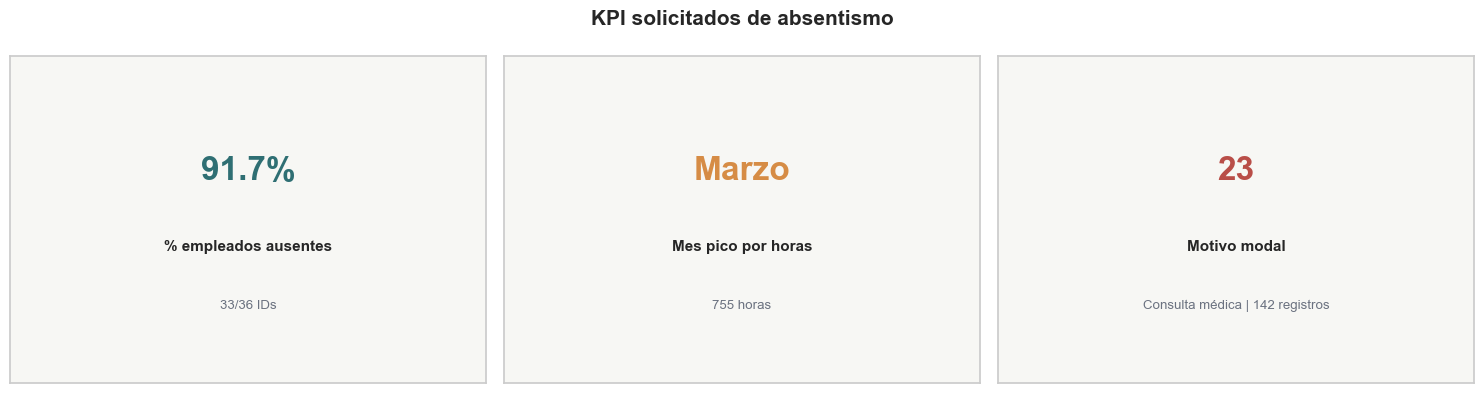

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("KPI solicitados de absentismo", fontsize=15, fontweight="bold")

tarjetas = [
    ["% empleados ausentes", f"{porcentaje_empleados_ausentes:.1f}%", f"{numero_empleados_ausentes}/{numero_total_empleados} IDs", COLOR_PRINCIPAL],
    ["Mes pico por horas", mes_pico_formula["Month_absence_name"], f"{mes_pico_formula['horas_absentismo']:.0f} horas", COLOR_SECUNDARIO],
    ["Motivo modal", str(int(motivo_modal_formula["Reason_absence"])), f"{motivo_modal_formula['Reason_absence_name']} | {int(motivo_modal_formula['frecuencia'])} registros", COLOR_ALERTA],
]

for ax, tarjeta in zip(axes, tarjetas):
    titulo, valor, detalle, color = tarjeta
    ax.set_facecolor("#F7F7F4")
    ax.text(0.5, 0.65, valor, ha="center", va="center", fontsize=24, fontweight="bold", color=color)
    ax.text(0.5, 0.42, titulo, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(0.5, 0.24, detalle, ha="center", va="center", fontsize=9.5, color=COLOR_GRIS)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estas tarjetas resumen los **3 KPI solicitados en el enunciado**: porcentaje de empleados ausentes, mes pico por horas de ausencia y motivo modal por frecuencia. Sirven como lectura ejecutiva antes de entrar en los gráficos de detalle: dimensión del problema, momento crítico del año y causa más repetida.

### Lectura de los KPI del enunciado

Estos KPI responden directamente a la pregunta semanal. El porcentaje dimensiona la magnitud del absentismo, el mes pico permite anticipar refuerzos y el motivo modal identifica la causa más frecuente. Conviene mantener separados el **motivo modal por frecuencia** y el **motivo con más horas**, porque pueden responder a problemas distintos: recurrencia frente a severidad.

## 7. Variación mensual: ¿cuándo se concentra el absentismo?


In [8]:
absentismo_por_mes = df_temporal.groupby(["Month_absence", "Month_absence_name"], as_index=False).agg({
    "ID": "nunique",
    "Tiene_ausencia": "sum",
    "Absenteeism_hours": ["sum", "mean"],
    "Work_load_Average_day": "mean",
    "Hit_target": "mean",
})

absentismo_por_mes.columns = [
    "Month_absence",
    "Month_absence_name",
    "empleados_unicos",
    "registros_ausencia",
    "horas_totales",
    "horas_media",
    "carga_media",
    "hit_target_medio",
]

absentismo_por_mes = absentismo_por_mes.sort_values("Month_absence")
absentismo_por_mes["%_horas_anuales"] = absentismo_por_mes["horas_totales"] / absentismo_por_mes["horas_totales"].sum() * 100

absentismo_por_mes.round(2)


,Month_absence,Month_absence_name,empleados_unicos,registros_ausencia,horas_totales,horas_media,carga_media,hit_target_medio,%_horas_anuales
0,1.00,Enero,13,44,212,4.71,315.49,96.56,4.20
1,2.00,Febrero,19,62,269,4.34,272.17,97.32,5.33
2,3.00,Marzo,22,79,755,9.10,270.37,97.34,14.97
3,4.00,Abril,21,49,476,9.52,276.57,94.82,9.44
4,5.00,Mayo,24,55,393,6.44,276.77,97.16,7.79
5,6.00,Junio,19,51,411,7.61,298.01,95.06,8.15
6,7.00,Julio,23,63,730,11.23,250.27,95.05,14.48
7,8.00,Agosto,21,54,288,5.33,238.01,92.94,5.71
8,9.00,Septiembre,17,43,291,5.60,265.04,86.92,5.77
9,10.00,Octubre,19,60,344,4.99,269.36,90.32,6.82


In [9]:
plot_data = absentismo_por_mes.copy()
plot_data["%_horas_absentismo"] = plot_data["horas_totales"] / plot_data["horas_totales"].sum() * 100
plot_data["texto_porcentaje"] = plot_data["%_horas_absentismo"].round(1).astype(str) + "%"

fig = px.bar(
    plot_data,
    x="Month_absence_name",
    y="horas_totales",
    text="texto_porcentaje",
    hover_data={
        "horas_totales": ":.0f",
        "%_horas_absentismo": ":.1f",
        "registros_ausencia": True,
        "empleados_unicos": True,
        "Month_absence_name": False,
        "texto_porcentaje": False,
    },
    labels={
        "Month_absence_name": "Mes",
        "horas_totales": "Horas totales",
        "%_horas_absentismo": "% sobre horas totales",
        "registros_ausencia": "Registros de ausencia",
        "empleados_unicos": "Empleados únicos",
    },
    title="",
)

fig.update_traces(marker_color=COLOR_PRINCIPAL, textposition="inside", textfont_color="white")
fig.update_layout(xaxis_tickangle=-35, showlegend=False)
fig.show()


### Lectura del gráfico

Este gráfico responde a **cómo varía el absentismo a lo largo del año**. Las barras muestran la magnitud en **horas totales** por mes; la cifra superior de cada barra es el total de horas y el porcentaje en blanco dentro de la barra indica qué parte del **total de horas de absentismo** aporta ese mes. Ese porcentaje se calcula como: `horas del mes / horas totales de absentismo * 100`.

El pico principal aparece en **marzo (755 horas; 15.0%)** y el segundo en **julio (730 horas; 14.5%)**. Para planificación, estos meses deberían revisarse antes de que lleguen: cobertura, turnos, vacaciones, refuerzos y medidas preventivas.

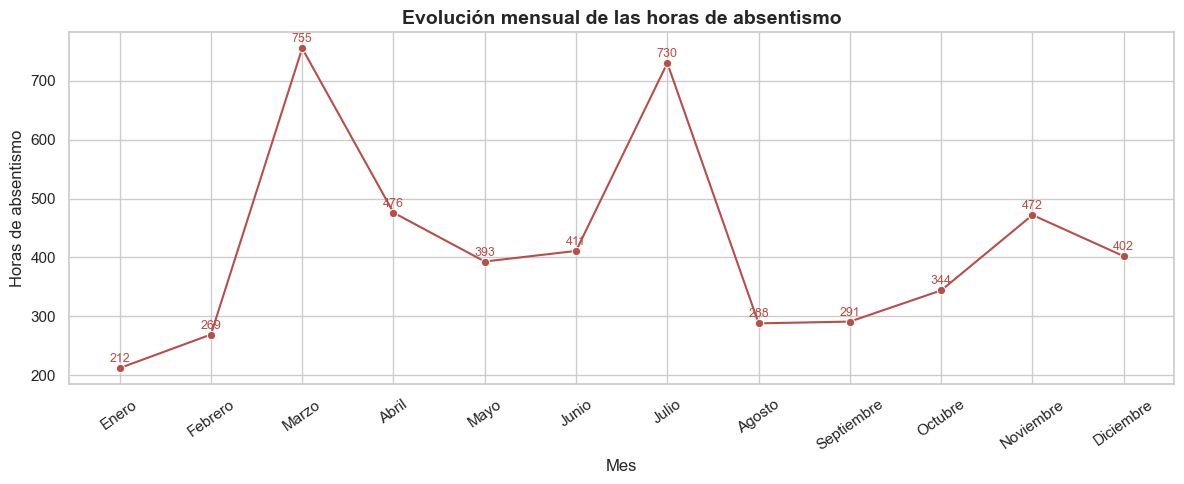

In [10]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=absentismo_por_mes, x="Month_absence_name", y="horas_totales", marker="o", color=COLOR_ALERTA)

plt.title("Evolución mensual de las horas de absentismo", fontsize=14, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Horas de absentismo")
plt.xticks(rotation=35)

for i, fila in absentismo_por_mes.iterrows():
    plt.text(i, fila["horas_totales"] + 10, f"{fila['horas_totales']:.0f}", ha="center", fontsize=9, color=COLOR_ALERTA)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico muestra únicamente la **evolución mensual de las horas de absentismo**. Refuerza la lectura temporal del gráfico anterior: el absentismo no se distribuye de forma uniforme y presenta picos claros en marzo y julio. Es útil como vista limpia de tendencia cuando no queremos mezclar el análisis con otras métricas operativas.

## 8. Motivos de ausencia: ¿qué explica más horas?


In [11]:
absentismo_por_motivo = df_clean.groupby(["Reason_absence", "Reason_absence_name"], as_index=False).agg({
    "ID": "count",
    "Tiene_ausencia": "sum",
    "Absenteeism_hours": ["sum", "mean"],
})

absentismo_por_motivo.columns = [
    "Reason_absence",
    "Reason_absence_name",
    "registros",
    "registros_ausencia",
    "horas_totales",
    "horas_media",
]

absentismo_por_motivo = absentismo_por_motivo.sort_values("horas_totales", ascending=False)
absentismo_por_motivo["%_horas"] = absentismo_por_motivo["horas_totales"] / absentismo_por_motivo["horas_totales"].sum() * 100

absentismo_por_motivo.round(2)


,Reason_absence,Reason_absence_name,registros,registros_ausencia,horas_totales,horas_media,%_horas
12,13.00,Sistema musculoesquelético,55,55,842,15.31,16.70
18,19.00,"Lesiones, intoxicaciones y consecuencias externas",40,40,729,18.23,14.46
21,23.00,Consulta médica,142,142,408,2.87,8.09
26,28.00,Consulta dental,108,108,329,3.05,6.52
10,11.00,Sistema digestivo,26,26,297,11.42,5.89
20,22.00,Seguimiento de paciente,37,37,285,7.70,5.65
9,10.00,Sistema respiratorio,25,25,276,11.04,5.47
24,26.00,Ausencia injustificada,33,33,240,7.27,4.76
17,18.00,Síntomas y hallazgos no clasificados,21,21,217,10.33,4.30
11,12.00,Piel y tejido subcutáneo,8,8,187,23.38,3.71


In [12]:
top_motivos = absentismo_por_motivo.sort_values("horas_totales", ascending=False).head(10).copy()
top_motivos["motivo"] = top_motivos["Reason_absence"].astype(int).astype(str) + " - " + top_motivos["Reason_absence_name"]

fig = px.scatter(
    top_motivos,
    x="registros_ausencia",
    y="horas_totales",
    size="horas_media",
    color="Reason_absence_name",
    text="Reason_absence",
    hover_name="motivo",
    hover_data={
        "registros_ausencia": True,
        "horas_totales": ":.0f",
        "horas_media": ":.2f",
        "Reason_absence_name": False,
        "Reason_absence": False,
        "motivo": False,
    },
    labels={
        "registros_ausencia": "Registros con ausencia",
        "horas_totales": "Horas totales",
        "horas_media": "Horas medias",
    },
    title="Motivos principales: frecuencia vs horas acumuladas",
)

fig.update_traces(textposition="middle center", textfont_color="white")
fig.update_layout(showlegend=False)
fig.show()


### Lectura del gráfico

Este gráfico compara **frecuencia de registros** y **horas acumuladas** sin mezclar unidades en dos ejes. Los motivos situados más arriba acumulan más horas; los situados más a la derecha aparecen más veces. El motivo **13 - Sistema musculoesquelético** destaca por horas acumuladas, mientras que el **23 - Consulta médica** destaca por frecuencia. Esta diferencia ayuda a separar acciones preventivas de salud/ergonomía frente a medidas de gestión de citas o cobertura puntual.

In [13]:
comparacion_motivos = absentismo_por_motivo[
    absentismo_por_motivo["Reason_absence"].isin([13, 23])
][["Reason_absence", "Reason_absence_name", "registros_ausencia", "horas_totales", "horas_media"]]

comparacion_motivos.round(2)


,Reason_absence,Reason_absence_name,registros_ausencia,horas_totales,horas_media
12,13.00,Sistema musculoesquelético,55,842,15.31
21,23.00,Consulta médica,142,408,2.87


### Lectura del gráfico

Este gráfico separa **frecuencia** y **severidad**. Algunos motivos aparecen muchas veces pero con pocas horas medias, como consultas médicas o dentales; otros aparecen menos, pero generan ausencias más largas. Esta distinción ayuda a decidir si la respuesta debe ser administrativa, preventiva o de sustitución operativa.



## 8.1 Motivos ICD vs no-ICD

El repositorio externo revisado propone separar los motivos incluidos en la clasificación ICD de los motivos administrativos o de consulta (`22-28`). Esta agrupación sí es útil para negocio porque permite distinguir entre absentismo asociado a enfermedad/lesión y ausencias de seguimiento, consultas o gestiones.


In [14]:
absentismo_por_grupo_motivo = df_clean.groupby("Reason_group", as_index=False).agg({
    "ID": "count",
    "Tiene_ausencia": "sum",
    "Absenteeism_hours": ["sum", "mean"],
})

absentismo_por_grupo_motivo.columns = [
    "Reason_group",
    "registros",
    "registros_ausencia",
    "horas_totales",
    "horas_media",
]

absentismo_por_grupo_motivo["%_horas"] = absentismo_por_grupo_motivo["horas_totales"] / absentismo_por_grupo_motivo["horas_totales"].sum() * 100
absentismo_por_grupo_motivo = absentismo_por_grupo_motivo.sort_values("horas_totales", ascending=False)

absentismo_por_grupo_motivo.round(2)


,Reason_group,registros,registros_ausencia,horas_totales,horas_media,%_horas
0,ICD / enfermedad,262,262,3543,13.52,70.26
2,No-ICD / consulta o gestión,401,400,1500,3.74,29.74
1,Motivo no informado,43,0,0,0.00,0.00


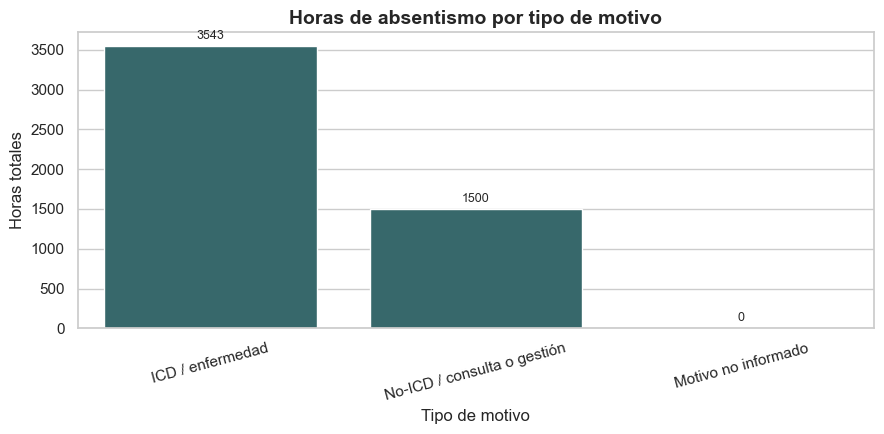

In [15]:

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=absentismo_por_grupo_motivo,
    x="Reason_group",
    y="horas_totales",
    color=COLOR_PRINCIPAL,
    ax=ax,
)

ax.set_title("Horas de absentismo por tipo de motivo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de motivo")
ax.set_ylabel("Horas totales")
ax.tick_params(axis="x", rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()



### Lectura del gráfico

Esta agrupación ayuda a responder **qué tipo de absentismo pesa más**. Si predominan las horas ICD, la respuesta de RRHH debe orientarse a prevención de salud, ergonomía y seguridad laboral; si pesan mucho las categorías no-ICD, puede haber margen para gestionar citas, consultas o procesos administrativos sin afectar tanto la operación. Es una lectura más accionable que mirar solo códigos sueltos.


## 9. Día de la semana y estación: señales para planificación


In [16]:
absentismo_por_dia = df_clean.groupby(["Day_week", "Day_week_name"], as_index=False).agg({
    "ID": "count",
    "Absenteeism_hours": ["sum", "mean"],
})
absentismo_por_dia.columns = ["Day_week", "Day_week_name", "registros", "horas_totales", "horas_media"]
absentismo_por_dia = absentismo_por_dia.sort_values("Day_week")

absentismo_por_estacion = df_clean.groupby(["Seasons", "Seasons_name"], as_index=False).agg({
    "ID": "count",
    "Absenteeism_hours": ["sum", "mean"],
})
absentismo_por_estacion.columns = ["Seasons", "Seasons_name", "registros", "horas_totales", "horas_media"]
absentismo_por_estacion = absentismo_por_estacion.sort_values("Seasons")

print("Absentismo por día")
display(absentismo_por_dia.round(2))

print("Absentismo por estación")
display(absentismo_por_estacion.round(2))


Absentismo por día


,Day_week,Day_week_name,registros,horas_totales,horas_media
0,2,Lunes,158,1483,9.39
1,3,Martes,150,1221,8.14
2,4,Miércoles,144,1081,7.51
3,5,Jueves,119,539,4.53
4,6,Viernes,135,719,5.33


Absentismo por estación


,Seasons,Seasons_name,registros,horas_totales,horas_media
0,1,Invierno,167,1236,7.40
1,2,Primavera,189,1221,6.46
2,3,Verano,173,1107,6.40
3,4,Otoño,177,1479,8.36


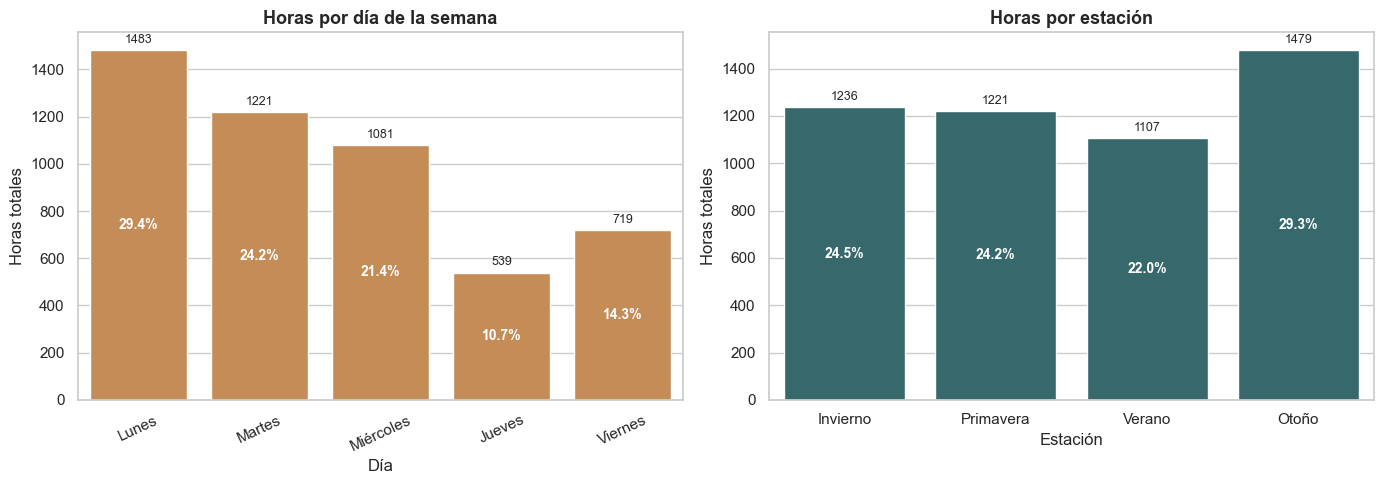

In [17]:
total_horas = df_clean["Absenteeism_hours"].sum()
absentismo_por_dia["%_horas"] = absentismo_por_dia["horas_totales"] / total_horas * 100
absentismo_por_estacion["%_horas"] = absentismo_por_estacion["horas_totales"] / total_horas * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=absentismo_por_dia, x="Day_week_name", y="horas_totales", color=COLOR_SECUNDARIO, ax=axes[0])
axes[0].set_title("Horas por día de la semana", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Horas totales")
axes[0].tick_params(axis="x", rotation=25)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

for i, fila in absentismo_por_dia.reset_index(drop=True).iterrows():
    axes[0].text(
        i,
        fila["horas_totales"] / 2,
        f"{fila['%_horas']:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

sns.barplot(data=absentismo_por_estacion, x="Seasons_name", y="horas_totales", color=COLOR_PRINCIPAL, ax=axes[1])
axes[1].set_title("Horas por estación", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Estación")
axes[1].set_ylabel("Horas totales")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

for i, fila in absentismo_por_estacion.reset_index(drop=True).iterrows():
    axes[1].text(
        i,
        fila["horas_totales"] / 2,
        f"{fila['%_horas']:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estos gráficos ayudan a anticipar necesidades de cobertura. La cifra superior muestra las **horas totales** y el porcentaje en blanco indica qué parte del **total de horas de absentismo** concentra cada día o estación. El absentismo se concentra más en **lunes**, por lo que el inicio de semana merece especial atención en la planificación. En estaciones, la lectura sirve como apoyo para prever periodos con más carga de ausencias.

## 10. Concentración por empleado


In [18]:
absentismo_por_empleado = df_clean.groupby("ID", as_index=False).agg({
    "Absenteeism_hours": ["count", "sum", "mean"],
    "Age": "first",
    "Service_time": "first",
    "Distance_Residence_Work": "first",
    "Education_name": "first",
    "Hit_target": "mean",
})

absentismo_por_empleado.columns = [
    "ID",
    "registros",
    "horas_totales",
    "horas_media",
    "edad",
    "antiguedad",
    "distancia_km",
    "educacion",
    "hit_target_medio",
]

absentismo_por_empleado = absentismo_por_empleado.sort_values("horas_totales", ascending=False)
absentismo_por_empleado["%_horas"] = absentismo_por_empleado["horas_totales"] / absentismo_por_empleado["horas_totales"].sum() * 100
absentismo_por_empleado["%_horas_acum"] = absentismo_por_empleado["%_horas"].cumsum()

absentismo_por_empleado.head(10).round(2)


,ID,registros,horas_totales,horas_media,edad,antiguedad,distancia_km,educacion,hit_target_medio,%_horas,%_horas_acum
13,14,29,476,16.41,34,14,12,Secundaria,95.69,9.44,9.44
10,11,40,450,11.25,33,13,36,Secundaria,93.85,8.92,18.36
2,3,97,444,4.58,38,18,51,Secundaria,94.76,8.80,27.17
27,28,75,343,4.57,28,9,26,Secundaria,94.89,6.80,33.97
33,34,50,333,6.66,37,10,10,Secundaria,94.62,6.60,40.57
35,36,34,311,9.15,50,18,13,Secundaria,94.32,6.17,46.74
19,20,42,306,7.29,36,11,50,Secundaria,94.57,6.07,52.81
8,9,8,262,32.75,58,16,14,Secundaria,95.88,5.20,58.00
14,15,36,251,6.97,40,12,31,Secundaria,92.42,4.98,62.98
23,24,28,251,8.96,41,16,25,Secundaria,94.14,4.98,67.96


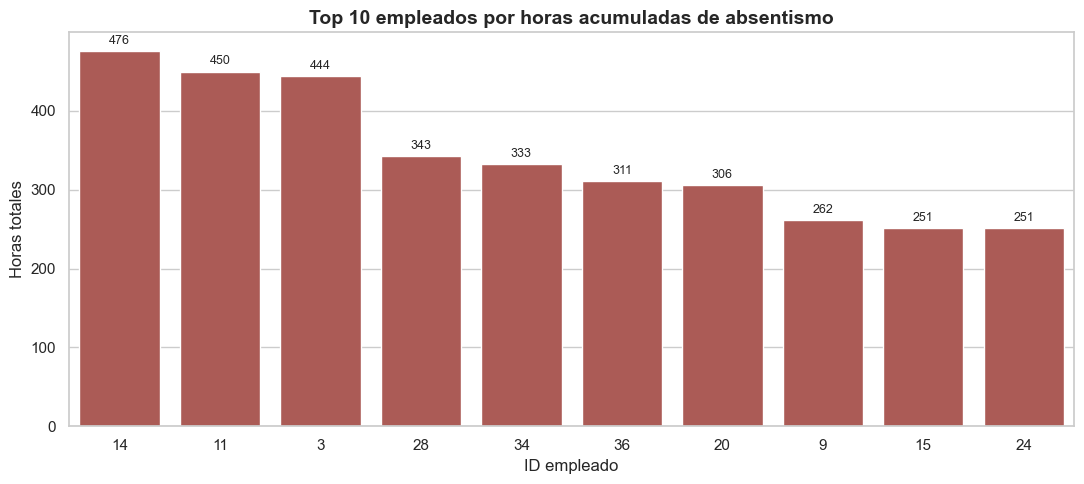

In [19]:
top_empleados = absentismo_por_empleado.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_empleados, x="ID", y="horas_totales", color=COLOR_ALERTA, order=top_empleados["ID"], ax=ax)
ax.set_title("Top 10 empleados por horas acumuladas de absentismo", fontsize=14, fontweight="bold")
ax.set_xlabel("ID empleado")
ax.set_ylabel("Horas totales")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### Lectura del gráfico

Este gráfico responde a la **concentración del absentismo por empleado**. Los 10 IDs con más horas acumulan cerca del **68%** de las horas totales, y los 5 primeros alrededor del **41%**. Para negocio, esto sugiere dos líneas de acción distintas: planificación agregada para los picos temporales y revisión individual confidencial para casos con carga acumulada alta.


In [20]:
participacion_top_5 = absentismo_por_empleado.head(5)["%_horas"].sum()
participacion_top_10 = absentismo_por_empleado.head(10)["%_horas"].sum()

concentracion = pd.DataFrame({
    "grupo": ["Top 5 empleados", "Top 10 empleados", "Resto"],
    "% horas totales": [
        participacion_top_5,
        participacion_top_10,
        100 - participacion_top_10,
    ],
})

concentracion.round(2)


,grupo,% horas totales
0,Top 5 empleados,40.57
1,Top 10 empleados,67.96
2,Resto,32.04


## 11. Variables operativas: carga, hit target y absentismo


In [21]:
columnas_corr = [
    "Absenteeism_hours",
    "Work_load_Average_day",
    "Hit_target",
    "Service_time",
    "Distance_Residence_Work",
    "Age",
    "Body_mass_index",
]

correlaciones_operativas = df_clean[columnas_corr].corr()[["Absenteeism_hours"]]
correlaciones_operativas.round(3)


,Absenteeism_hours
Absenteeism_hours,1.00
Work_load_Average_day,0.02
Hit_target,0.03
Service_time,0.03
Distance_Residence_Work,-0.09
Age,0.07
Body_mass_index,-0.05


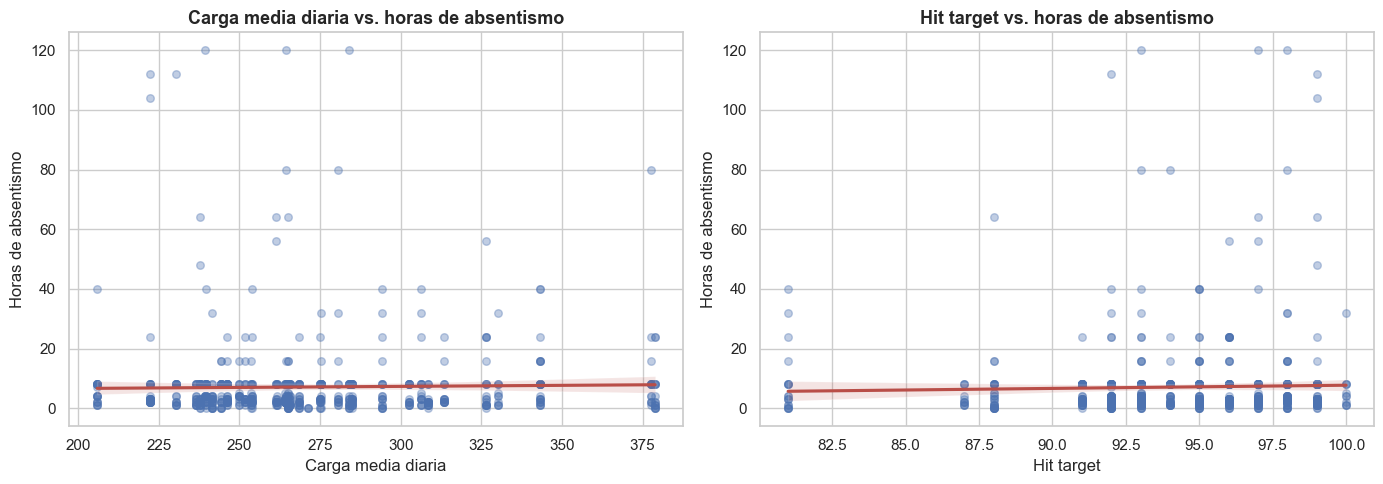

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_clean,
    x="Work_load_Average_day",
    y="Absenteeism_hours",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"color": COLOR_ALERTA},
    ax=axes[0],
)
axes[0].set_title("Carga media diaria vs. horas de absentismo", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Carga media diaria")
axes[0].set_ylabel("Horas de absentismo")

sns.regplot(
    data=df_clean,
    x="Hit_target",
    y="Absenteeism_hours",
    scatter_kws={"alpha": 0.35, "s": 30},
    line_kws={"color": COLOR_ALERTA},
    ax=axes[1],
)
axes[1].set_title("Hit target vs. horas de absentismo", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Hit target")
axes[1].set_ylabel("Horas de absentismo")

plt.tight_layout()
plt.show()


### Lectura del gráfico

Estos gráficos evalúan si `Work_load_Average_day` o `Hit_target` explican directamente las horas de absentismo. La relación observada es muy débil, así que no conviene afirmar que más carga o mejor/peor cumplimiento causen más ausencias con este análisis descriptivo. Su valor está en incorporarlos como variables de control para detectar meses operativamente sensibles.



## 11.1 BMI categorizado como variable exploratoria de bienestar

Del repositorio externo también sirve la idea de categorizar el `Body_mass_index` con los cortes internacionales habituales. En este análisis se usa solo como variable exploratoria de bienestar: puede ayudar a segmentar, pero no debe presentarse como causa del absentismo.


In [23]:
def categorizar_bmi(bmi):
    if bmi < 18.5:
        return "Bajo peso"
    elif bmi < 25:
        return "Peso normal"
    elif bmi < 30:
        return "Sobrepeso"
    else:
        return "Obesidad"

df_clean["BMI_group"] = df_clean["Body_mass_index"].apply(categorizar_bmi)

bmi_absentismo = df_clean.groupby("BMI_group", as_index=False).agg({
    "ID": "nunique",
    "Absenteeism_hours": ["count", "sum", "mean"],
})

bmi_absentismo.columns = ["BMI_group", "empleados_unicos", "registros", "horas_totales", "horas_media"]
bmi_absentismo = bmi_absentismo.sort_values("BMI_group")

bmi_absentismo.round(2)


,BMI_group,empleados_unicos,registros,horas_totales,horas_media
0,Obesidad,9,227,1421,6.26
1,Peso normal,13,254,1712,6.74
2,Sobrepeso,14,225,1910,8.49


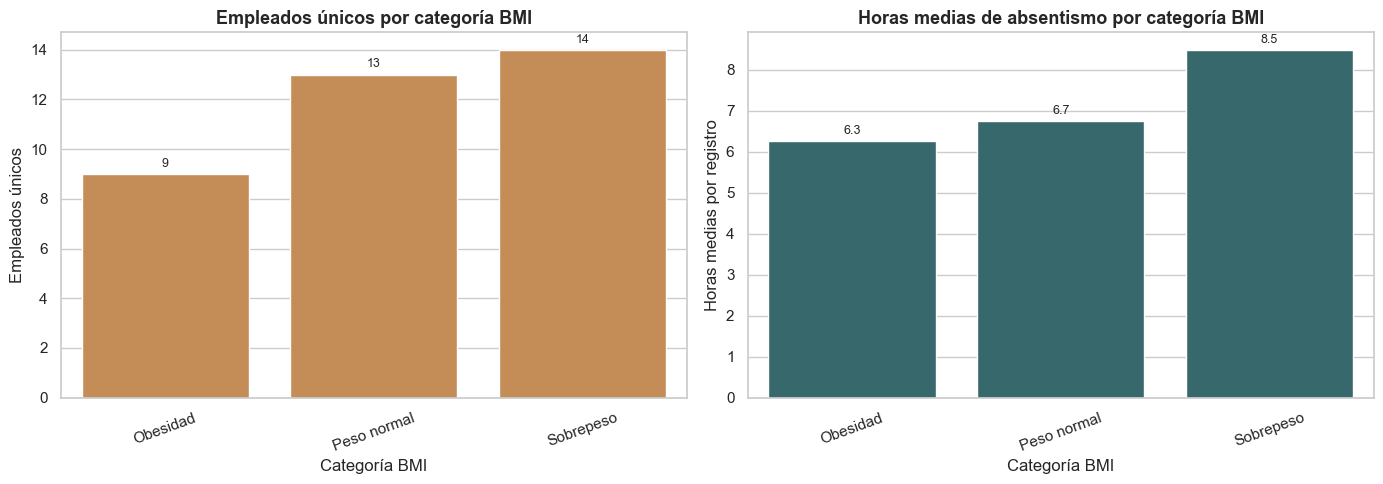

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=bmi_absentismo, x="BMI_group", y="empleados_unicos", color=COLOR_SECUNDARIO, ax=axes[0])
axes[0].set_title("Empleados únicos por categoría BMI", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Categoría BMI")
axes[0].set_ylabel("Empleados únicos")
axes[0].tick_params(axis="x", rotation=20)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=9)

sns.barplot(data=bmi_absentismo, x="BMI_group", y="horas_media", color=COLOR_PRINCIPAL, ax=axes[1])
axes[1].set_title("Horas medias de absentismo por categoría BMI", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Categoría BMI")
axes[1].set_ylabel("Horas medias por registro")
axes[1].tick_params(axis="x", rotation=20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()



### Lectura del gráfico

La categorización de BMI aporta contexto de bienestar, pero no debe convertirse en una conclusión causal. Sirve para comprobar si algún grupo concentra más horas medias y para decidir si merece la pena incluir esta variable en el dashboard o dejarla como análisis complementario. Si se presenta, conviene hacerlo con lenguaje prudente y agregado.


## 12. Mapa de calor para planificación


In [25]:
prioridad_mes_dia = df_temporal.groupby(
    ["Month_absence", "Month_absence_name", "Day_week", "Day_week_name"],
    as_index=False
)["Absenteeism_hours"].sum()

prioridad_mes_dia = prioridad_mes_dia.rename(columns={"Absenteeism_hours": "horas_totales"})
prioridad_mes_dia["%_horas"] = prioridad_mes_dia["horas_totales"] / df_temporal["Absenteeism_hours"].sum() * 100

prioridad_mes_dia = prioridad_mes_dia.sort_values("%_horas", ascending=False)
prioridad_mes_dia.head(10).round(2)


,Month_absence,Month_absence_name,Day_week,Day_week_name,horas_totales,%_horas
31,7.00,Julio,3,Martes,323,6.40
56,12.00,Diciembre,3,Martes,275,5.45
10,3.00,Marzo,2,Lunes,262,5.20
50,11.00,Noviembre,2,Lunes,247,4.90
30,7.00,Julio,2,Lunes,236,4.68
17,4.00,Abril,4,Miércoles,234,4.64
11,3.00,Marzo,3,Martes,221,4.38
27,6.00,Junio,4,Miércoles,127,2.52
12,3.00,Marzo,4,Miércoles,124,2.46
25,6.00,Junio,2,Lunes,120,2.38


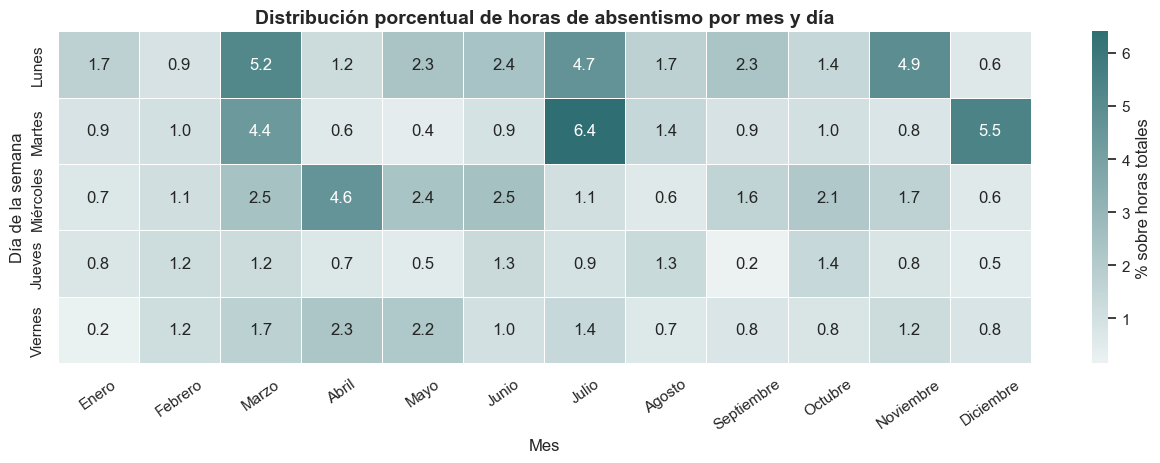

In [26]:
meses_orden = absentismo_por_mes["Month_absence_name"].tolist()
dias_orden = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]

mapa_mes_dia = prioridad_mes_dia.pivot(
    index="Day_week_name",
    columns="Month_absence_name",
    values="%_horas"
)

mapa_mes_dia = mapa_mes_dia.reindex(index=dias_orden, columns=meses_orden).fillna(0)
paleta_heatmap = sns.light_palette(COLOR_PRINCIPAL, as_cmap=True)

plt.figure(figsize=(13, 4.8))
sns.heatmap(
    mapa_mes_dia,
    annot=True,
    fmt=".1f",
    cmap=paleta_heatmap,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% sobre horas totales"}
)

plt.title("Distribución porcentual de horas de absentismo por mes y día", fontsize=14, fontweight="bold")
plt.xlabel("Mes")
plt.ylabel("Día de la semana")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


### Lectura del gráfico

Este mapa de calor responde mejor a la pregunta de **cómo anticiparse para reforzar la planificación**. No usa las horas absolutas como previsión directa, sino el **porcentaje de horas que concentra cada combinación de mes y día** dentro del histórico. Las celdas más oscuras indican momentos donde históricamente se acumuló más absentismo y, por tanto, donde tendría sentido prever más cobertura, revisar turnos o preparar sustituciones.

## 13. Impacto gerencial del absentismo

Para gerencia, las horas absolutas no son suficientes. Decir que hay **5.043 horas** de absentismo explica el volumen, pero no traduce el impacto operativo. Por eso se convierten las horas en tres indicadores más fáciles de interpretar:

- **Tasa estimada de absentismo:** qué parte de la capacidad laboral teórica se perdió por absentismo.
- **Jornadas equivalentes perdidas:** cuántos días laborales de 8 horas representan las horas de ausencia.
- **Capacidad FTE equivalente:** cuántos recursos a tiempo completo equivalen esas horas perdidas.

**Supuestos usados:** el dataset cubre el periodo **julio 2007 - julio 2010**, se consideran **36 recursos observados**, jornada estándar de **8 horas/día** y **252 días laborables/año** como aproximación de gestión. No es una tasa oficial de empresa, porque no tenemos calendario laboral real, turnos, vacaciones ni festivos.


In [27]:
# Indicadores de impacto gerencial del absentismo
periodo_anios = 3  # julio 2007 - julio 2010
horas_jornada = 8
dias_laborables_anio_estimados = 252

recursos_observados = df_clean["ID"].nunique()
horas_absentismo_totales = df_clean["Absenteeism_hours"].sum()

horas_teoricas_periodo = (
    recursos_observados
    * horas_jornada
    * dias_laborables_anio_estimados
    * periodo_anios
)

tasa_absentismo_estimada = horas_absentismo_totales / horas_teoricas_periodo * 100
jornadas_equivalentes_perdidas = horas_absentismo_totales / horas_jornada
fte_anios_perdidos = horas_absentismo_totales / (horas_jornada * dias_laborables_anio_estimados)
fte_anual_promedio = fte_anios_perdidos / periodo_anios
horas_anuales_promedio = horas_absentismo_totales / periodo_anios
jornadas_anuales_promedio = jornadas_equivalentes_perdidas / periodo_anios

impacto_gerencial = pd.DataFrame({
    "Indicador": [
        "Tasa estimada de absentismo",
        "Horas totales de absentismo",
        "Jornadas equivalentes perdidas",
        "Capacidad acumulada equivalente",
        "Capacidad anual promedio perdida",
    ],
    "Resultado": [
        f"{tasa_absentismo_estimada:.1f}%",
        f"{horas_absentismo_totales:,.0f} h".replace(",", "."),
        f"{jornadas_equivalentes_perdidas:.0f} jornadas de 8h",
        f"{fte_anios_perdidos:.1f} recursos-año",
        f"{fte_anual_promedio:.1f} FTE/año",
    ],
    "Cómo se interpreta": [
        "Parte estimada de la capacidad laboral teórica perdida por absentismo.",
        "Volumen total de ausencia registrado en los 36 recursos observados.",
        "Traducción de las horas a días laborales completos.",
        "Equivalente acumulado de capacidad full-time perdida en todo el periodo.",
        "Pérdida media anual de capacidad dentro de la muestra observada.",
    ]
})

impacto_gerencial


,Indicador,Resultado,Cómo se interpreta
0,Tasa estimada de absentismo,2.3%,Parte estimada de la capacidad laboral teórica...
1,Horas totales de absentismo,5.043 h,Volumen total de ausencia registrado en los 36...
2,Jornadas equivalentes perdidas,630 jornadas de 8h,Traducción de las horas a días laborales compl...
3,Capacidad acumulada equivalente,2.5 recursos-año,Equivalente acumulado de capacidad full-time p...
4,Capacidad anual promedio perdida,0.8 FTE/año,Pérdida media anual de capacidad dentro de la ...


### Lectura gerencial

El absentismo observado equivale aproximadamente a **630 jornadas laborales de 8 horas** en todo el periodo. Traducido a capacidad, supone unos **2,5 recursos-año acumulados** o alrededor de **0,8 FTE por año**.

Esta lectura es más útil para dirección que mirar solo horas absolutas: permite explicar que el absentismo no es únicamente una incidencia de RRHH, sino una pérdida de capacidad operativa que debe planificarse.

La tasa estimada de absentismo es de aproximadamente **2,3%** bajo los supuestos indicados. Como no tenemos calendario laboral real ni plantilla externa al dataframe, este valor debe presentarse como **estimación de gestión**, no como tasa oficial auditada.


## 14. Respuesta a las preguntas de negocio


In [28]:
mes_pico = absentismo_por_mes.sort_values("horas_totales", ascending=False).iloc[0]
mes_segundo = absentismo_por_mes.sort_values("horas_totales", ascending=False).iloc[1]
motivo_pico = absentismo_por_motivo.sort_values("horas_totales", ascending=False).iloc[0]
motivo_modal_conclusion = motivo_modal_formula
dia_pico = absentismo_por_dia.sort_values("horas_totales", ascending=False).iloc[0]
estacion_pico = absentismo_por_estacion.sort_values("horas_totales", ascending=False).iloc[0]

top3_meses = absentismo_por_mes.sort_values("horas_totales", ascending=False).head(3)["Month_absence_name"].tolist()
top3_meses = ", ".join(top3_meses)

respuesta = f"""
### Conclusiones ejecutivas

**Magnitud:** hay **{horas_totales:.0f} horas de absentismo** y **{registros_ausencia} registros con más de 0 horas**. El dataset contiene **{total_empleados} empleados únicos**, de los cuales **{empleados_con_ausencia} ({empleados_con_ausencia / total_empleados * 100:.1f}%)** tienen al menos una ausencia registrada.

**Variación anual:** el mes con mayor carga es **{mes_pico['Month_absence_name']}**, con **{mes_pico['horas_totales']:.0f} horas**, seguido de **{mes_segundo['Month_absence_name']}** con **{mes_segundo['horas_totales']:.0f} horas**. Los tres meses de mayor presión son: **{top3_meses}**.

**Motivos principales:** el motivo modal por frecuencia es **{int(motivo_modal_conclusion['Reason_absence'])} - {motivo_modal_conclusion['Reason_absence_name']}**, con **{int(motivo_modal_conclusion['frecuencia'])} registros**. En cambio, el motivo que más horas acumula es **{int(motivo_pico['Reason_absence'])} - {motivo_pico['Reason_absence_name']}**, con **{motivo_pico['horas_totales']:.0f} horas**.

**Planificación operativa:** el día con más horas es **{dia_pico['Day_week_name']}** y la estación con más horas es **{estacion_pico['Seasons_name']}**. Para anticiparse, conviene reforzar la planificación en los meses pico y revisar los motivos que acumulan más horas.
"""

Markdown(respuesta)



### Conclusiones ejecutivas

**Magnitud:** hay **5043 horas de absentismo** y **662 registros con más de 0 horas**. El dataset contiene **36 empleados únicos**, de los cuales **33 (91.7%)** tienen al menos una ausencia registrada.

**Variación anual:** el mes con mayor carga es **Marzo**, con **755 horas**, seguido de **Julio** con **730 horas**. Los tres meses de mayor presión son: **Marzo, Julio, Abril**.

**Motivos principales:** el motivo modal por frecuencia es **23 - Consulta médica**, con **142 registros**. En cambio, el motivo que más horas acumula es **13 - Sistema musculoesquelético**, con **842 horas**.

**Planificación operativa:** el día con más horas es **Lunes** y la estación con más horas es **Otoño**. Para anticiparse, conviene reforzar la planificación en los meses pico y revisar los motivos que acumulan más horas.


## 15. Recomendaciones de negocio

1. **Planificar refuerzos antes de los meses pico:** preparar cobertura temporal o redistribución de turnos antes de marzo y julio, que concentran más horas.
2. **Actuar sobre los motivos de mayor impacto:** priorizar prevención ergonómica y salud musculoesquelética, además de revisar casos de lesiones y consultas médicas frecuentes.
3. **Separar seguimiento individual y planificación agregada:** los empleados con más horas acumuladas requieren análisis confidencial caso a caso; los picos mensuales requieren decisiones de capacidad.
4. **Crear alertas tempranas:** usar el mapa de calor mes-día para marcar cuándo se concentra mayor porcentaje histórico de horas de absentismo.
5. **Validar el denominador de plantilla:** para convertir el KPI en tasa real de absentismo de empresa, hace falta conocer el total de empleados activos, incluidos los que no tienen registros.


## 16. Tablas listas para dashboard


In [29]:
tablas_dashboard = {
    "kpi_absentismo": kpi_absentismo,
    "kpi_formulas_desafio": kpi_formulas_desafio,
    "impacto_gerencial": impacto_gerencial,
    "absentismo_por_mes": absentismo_por_mes.round(2),
    "absentismo_por_motivo": absentismo_por_motivo.round(2),
    "absentismo_por_grupo_motivo": absentismo_por_grupo_motivo.round(2),
    "absentismo_por_dia": absentismo_por_dia.round(2),
    "absentismo_por_estacion": absentismo_por_estacion.round(2),
    "absentismo_por_empleado": absentismo_por_empleado.round(2),
    "prioridad_mes_dia": prioridad_mes_dia.round(2),
    "bmi_absentismo": bmi_absentismo.round(2),
}

for nombre, tabla in tablas_dashboard.items():
    print(f"{nombre}: {tabla.shape[0]} filas x {tabla.shape[1]} columnas")


kpi_absentismo: 8 filas x 2 columnas
kpi_formulas_desafio: 3 filas x 3 columnas
impacto_gerencial: 5 filas x 3 columnas
absentismo_por_mes: 12 filas x 9 columnas
absentismo_por_motivo: 27 filas x 7 columnas
absentismo_por_grupo_motivo: 3 filas x 6 columnas
absentismo_por_dia: 5 filas x 6 columnas
absentismo_por_estacion: 4 filas x 6 columnas
absentismo_por_empleado: 36 filas x 11 columnas
prioridad_mes_dia: 60 filas x 6 columnas
bmi_absentismo: 3 filas x 5 columnas
